# Notebook 01 — RF Fault Detection with Autoencoders

**CAS 2026 · AI for Medical Accelerators**

In this notebook you will:
1. Generate a synthetic dataset of RF cavity IQ waveforms (4 classes)
2. Visualise the waveforms to understand what each fault looks like
3. Train a convolutional autoencoder on **normal pulses only**
4. Use reconstruction error as an anomaly score to detect faults
5. Evaluate with ROC curve and confusion matrix

**Key idea:** In clinical settings, fault data is rare — you cannot collect thousands of fault examples. The autoencoder is trained on normal operation only. Faults appear as high reconstruction error.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aghribi/cas2026-ai-medical-accelerators/blob/main/notebooks/01_fault_detection/notebook.ipynb)

In [1]:
# Run this cell only on Google Colab
import sys
if 'google.colab' in sys.modules:
    !pip install -q torch plotly scikit-learn
    !git clone --quiet https://github.com/aghribi/cas2026-ai-medical-accelerators.git
    sys.path.insert(0, 'cas2026-ai-medical-accelerators/notebooks/01_fault_detection')

In [2]:
import plotly.io as pio; pio.renderers.default = "notebook_connected"
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
print('Imports OK')

Imports OK


## 1 · Generate synthetic IQ waveforms

In [3]:
from generate_data import generate_dataset, CLASS_NAMES

X, y, class_names = generate_dataset(n_per_class=1_000, n_points=256)
print(f'Dataset shape : {X.shape}  (N, channels, time_points)')
print(f'Labels shape  : {y.shape}')
print(f'Classes       : {class_names}')
print(f'Class balance : {np.bincount(y)}')

Dataset shape : (4000, 2, 256)  (N, channels, time_points)
Labels shape  : (4000,)
Classes       : ['normal', 'quench', 'detuning', 'multipacting']
Class balance : [1000 1000 1000 1000]


## 2 · Visualise one example of each class

In [4]:
COLORS = ['#22d3ee', '#f87171', '#fb923c', '#a78bfa']
t = np.linspace(0, 1, 256)

fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[f'{n} — I' for n in class_names] + [f'{n} — Q' for n in class_names],
    vertical_spacing=0.12, horizontal_spacing=0.06,
)

for col, (label, color) in enumerate(zip(range(4), COLORS), 1):
    idx = np.where(y == label)[0][0]          # first example of each class
    I, Q = X[idx, 0], X[idx, 1]
    for row, signal in enumerate([I, Q], 1):
        fig.add_trace(
            go.Scatter(x=t, y=signal, line=dict(color=color, width=1.5),
                       name=class_names[label], showlegend=(col == 1 and row == 1)),
            row=row, col=col,
        )

fig.update_layout(
    height=500, title_text='Synthetic RF cavity IQ waveforms — one example per class',
    paper_bgcolor='#0d1b2a', plot_bgcolor='#111f30',
    font=dict(color='#e2e8f0', size=11),
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor='#1e3048')
fig.show()

## 3 · Train/test split and tensors

**Important:** training set contains **only normal pulses**. The model never sees a fault during training.

In [5]:
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% test
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Training set: NORMAL only (label 0)
mask_normal = y_train_all == 0
X_train_normal = torch.tensor(X_train_all[mask_normal])

X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

print(f'Training on {len(X_train_normal)} normal pulses')
print(f'Testing on  {len(X_test)} pulses ({np.bincount(y_test)})')

Training on 800 normal pulses
Testing on  800 pulses ([200 200 200 200])


## 4 · Define the convolutional autoencoder

In [6]:
class RFAutoencoder(nn.Module):
    """1-D convolutional autoencoder for IQ waveform anomaly detection."""

    def __init__(self, seq_len: int = 256, latent_dim: int = 16):
        super().__init__()
        # Encoder: (batch, 2, seq_len) → (batch, latent_dim)
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=8, stride=4, padding=2),   # → (32, 64)
            nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=1),  # → (64, 32)
            nn.GELU(),
            nn.Flatten(),                                            # → (2048,)
            nn.Linear(64 * 32, latent_dim),
        )
        # Decoder: (batch, latent_dim) → (batch, 2, seq_len)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 32),
            nn.Unflatten(1, (64, 32)),
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose1d(32, 2,  kernel_size=8, stride=4, padding=2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


def anomaly_score(model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    """Per-pulse mean squared reconstruction error → anomaly score."""
    with torch.no_grad():
        recon = model(x)
        return ((x - recon) ** 2).mean(dim=(1, 2))   # shape: (batch,)


model = RFAutoencoder(seq_len=256, latent_dim=16)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

Model parameters: 85,138


## 5 · Train the autoencoder (normal pulses only)

In [7]:
EPOCHS = 50
BATCH  = 64
LR     = 1e-3

loader    = DataLoader(TensorDataset(X_train_normal), batch_size=BATCH, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses = []
model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for (batch,) in loader:
        recon = model(batch)
        loss  = nn.functional.mse_loss(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    scheduler.step()
    train_losses.append(epoch_loss / len(X_train_normal))
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  loss={train_losses[-1]:.6f}')

print('Training complete.')

Epoch  10/50  loss=0.000681


Epoch  20/50  loss=0.000626


Epoch  30/50  loss=0.000623


Epoch  40/50  loss=0.000623


Epoch  50/50  loss=0.000622
Training complete.


In [8]:
fig = go.Figure(go.Scatter(y=train_losses, mode='lines', line=dict(color='#22d3ee', width=2)))
fig.update_layout(
    title='Training loss (reconstruction MSE on normal pulses)',
    xaxis_title='Epoch', yaxis_title='MSE',
    paper_bgcolor='#0d1b2a', plot_bgcolor='#111f30',
    font=dict(color='#e2e8f0'),
)
fig.show()

## 6 · Evaluate — anomaly scores and ROC curve

In [9]:
model.eval()
scores  = anomaly_score(model, X_test_t).numpy()
y_true  = (y_test > 0).astype(int)   # 0 = normal, 1 = any fault

auc = roc_auc_score(y_true, scores)
print(f'ROC-AUC (normal vs. any fault): {auc:.3f}')

# Threshold at 95th percentile of normal-pulse scores
threshold   = np.percentile(scores[y_test == 0], 95)
predictions = (scores > threshold).astype(int)

from sklearn.metrics import classification_report
print('\nClassification report (binary: normal vs fault):')
print(classification_report(y_true, predictions, target_names=['normal', 'fault']))

ROC-AUC (normal vs. any fault): 1.000

Classification report (binary: normal vs fault):
              precision    recall  f1-score   support

      normal       1.00      0.95      0.97       200
       fault       0.98      1.00      0.99       600

    accuracy                           0.99       800
   macro avg       0.99      0.97      0.98       800
weighted avg       0.99      0.99      0.99       800



In [10]:
fpr, tpr, _ = roc_curve(y_true, scores)

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    f'ROC curve (AUC = {auc:.3f})',
    'Anomaly score distribution per class',
])

# ROC
fig.add_trace(go.Scatter(x=fpr, y=tpr, fill='tozeroy',
    line=dict(color='#22d3ee'), name='Autoencoder'), row=1, col=1)
fig.add_trace(go.Scatter(x=[0,1], y=[0,1],
    line=dict(color='#475569', dash='dash'), name='Random', showlegend=False), row=1, col=1)

# Score histograms
for label, name, color in zip(range(4), CLASS_NAMES, COLORS):
    s = scores[y_test == label]
    fig.add_trace(go.Histogram(x=s, nbinsx=40, name=name,
        marker_color=color, opacity=0.65), row=1, col=2)

fig.add_vline(x=threshold, line=dict(color='white', dash='dot', width=1.5),
    annotation_text='Threshold', row=1, col=2)

fig.update_layout(
    height=420, barmode='overlay',
    paper_bgcolor='#0d1b2a', plot_bgcolor='#111f30',
    font=dict(color='#e2e8f0', size=11),
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor='#1e3048')
fig.show()

## 7 · Bonus — Multi-class classifier (Random Forest)

If you do have some fault labels (e.g., from historical logs), a supervised classifier gives much sharper per-class accuracy. Here we use the latent representation of the autoencoder as features.

Multi-class accuracy: 0.99875


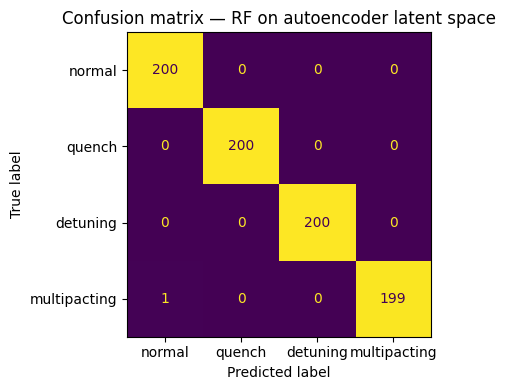

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Extract latent vectors as features
def encode(model, X):
    model.eval()
    with torch.no_grad():
        return model.encoder(torch.tensor(X)).numpy()

X_train_latent = encode(model, X_train_all)
X_test_latent  = encode(model, X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_latent, y_train_all)
y_pred = clf.predict(X_test_latent)

print('Multi-class accuracy:', (y_pred == y_test).mean())
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion matrix — RF on autoencoder latent space')
plt.tight_layout(); plt.show()

## 8 · Explainability — which waveform regions drive the anomaly score?

We use **gradient saliency** (∂score/∂input): for each waveform sample, how much does the anomaly score change if we perturb that sample by ε?

This is a model-agnostic attribution technique — it works with any differentiable model and requires no extra package.

**Expected results:**
- *Normal*: flat, low saliency — the model reconstructs everything well
- *Quench*: spike at the quench point — the sudden amplitude drop is the anomalous feature
- *Detuning*: elevated Q channel — off-resonance energy shows up in quadrature
- *Multipacting*: oscillatory pattern in the flat-top region


In [12]:

# Gradient saliency: |∂(anomaly_score)/∂(input)| at each time step
# High saliency = that part of the waveform drives the anomaly score most
model.eval()
t = np.linspace(0, 1, 256)
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[f'{n} — I' for n in CLASS_NAMES] + [f'{n} — Q' for n in CLASS_NAMES],
    vertical_spacing=0.12, horizontal_spacing=0.06,
)

for col, (label, name, color) in enumerate(zip(range(4), CLASS_NAMES, COLORS), 1):
    idx   = np.where(y_test == label)[0][0]
    x_in  = torch.tensor(X_test[idx : idx + 1], requires_grad=True)

    recon = model(x_in)
    score = ((x_in - recon) ** 2).mean()
    score.backward()

    saliency = x_in.grad.abs().squeeze(0).numpy()   # (2, 256)

    for row, ch in enumerate([0, 1], 1):
        fig.add_trace(go.Scatter(
            x=t, y=saliency[ch],
            fill='tozeroy',
            line=dict(color=color, width=1.5),
            showlegend=False,
        ), row=row, col=col)

fig.update_layout(
    height=480,
    title_text='Gradient attribution — which waveform regions drive the anomaly score?',
    paper_bgcolor='#0d1b2a', plot_bgcolor='#111f30',
    font=dict(color='#e2e8f0', size=11),
)
fig.update_xaxes(showgrid=False, title_text='Normalised time')
fig.update_yaxes(showgrid=True, gridcolor='#1e3048')
fig.show()

print('Interpretation:')
print('  Normal      — low, uniform attribution: reconstruction matches everywhere')
print('  Quench      — sharp spike at quench onset: the sudden drop is the anomalous region')
print('  Detuning    — elevated Q channel: off-resonance energy stored in the quadrature component')
print('  Multipacting— oscillatory pattern: the flat-top oscillations inflate the reconstruction error')


Interpretation:
  Normal      — low, uniform attribution: reconstruction matches everywhere
  Quench      — sharp spike at quench onset: the sudden drop is the anomalous region
  Detuning    — elevated Q channel: off-resonance energy stored in the quadrature component
  Multipacting— oscillatory pattern: the flat-top oscillations inflate the reconstruction error


---
## Next steps
- Try increasing `latent_dim` — does it help or hurt anomaly detection?
- Try different threshold values and see the precision/recall trade-off
- **Notebook 02** → Beam tuning with Bayesian optimisation and Cheetah